# Baseline Evaluation

Do simple baselines rank market states and concentrate edge in tails?

**Baselines:**
1. `microprice_minus_mid` — single feature score
2. `imbalance_1` — single feature score
3. Ridge regression on all features

**Split:** forward-only by fixed-duration windows from recording start, with purge at each boundary. Split configuration is defined in code below.

**Primary horizon:** h=500ms | **Secondary:** h=1000ms

## Setup

In [72]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from src.analysis.io import load_dataset_with_meta
from src.analysis.market_context import attach_segment_id, label_profile
from src.dataset.schema import FEATURE_COLUMNS, LABEL_COL

from catboost import CatBoostRegressor

pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

## Paths & dataset selection

In [73]:
DS_DIR = Path("../data/datasets/binance/BTCUSDT_v2")

HORIZONS = {
    500:  DS_DIR / "dataset_d4D_i100_tw1000_w600_h500.parquet",
    1000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h1000.parquet",
}

PRIMARY_H = 500
REF_PRICE = 69_492.49  # median midprice from book replay

## Load dataset

In [74]:
def load(horizon_ms: int) -> tuple[pd.DataFrame, dict]:
    df, meta = load_dataset_with_meta(HORIZONS[horizon_ms])
    attach_segment_id(df, int(meta["interval_ms"]))
    return df, meta


ds, ds_meta = load(PRIMARY_H)
horizon_ms = int(ds_meta["horizon_ms"])
interval_ms = int(ds_meta["interval_ms"])

print(f"Loaded h={horizon_ms}ms: {len(ds):,} rows")
print(f"Time range: {ds['datetime'].min()} → {ds['datetime'].max()}")
total_hours = (ds["timestamp"].max() - ds["timestamp"].min()) / 3600000
print(f"Duration: {total_hours:.1f}h = {total_hours / 24:.2f} days")

Loaded h=500ms: 3,402,297 rows
Time range: 2026-03-23 20:37:35.300000+00:00 → 2026-03-27 20:27:40.300000+00:00
Duration: 95.8h = 3.99 days


## Split configuration

Forward-only split by equal-duration windows from recording start, with purge at each boundary.
Set `TRAIN_DAYS`, `VAL_DAYS`, `TEST_DAYS` below — the code computes boundaries from actual dataset duration.

In [75]:
# Number of 24h days for each split (from recording start, sequential).
TRAIN_DAYS = 2
VAL_DAYS = 1
TEST_DAYS = 1

DAY_MS = 24 * 3600 * 1000
t0 = ds["timestamp"].min()
total_days = (ds["timestamp"].max() - t0) / DAY_MS
required_days = TRAIN_DAYS + VAL_DAYS + TEST_DAYS
print(f"Dataset duration: {total_days:.2f} days")
print(f"Required: {required_days} days (train={TRAIN_DAYS}, val={VAL_DAYS}, test={TEST_DAYS})")
assert total_days >= required_days - 0.05, f"Not enough data: have {total_days:.2f}, need {required_days}"

# Compute boundaries in ms from t0
train_end = t0 + TRAIN_DAYS * DAY_MS
val_end   = train_end + VAL_DAYS * DAY_MS
test_end  = val_end + TEST_DAYS * DAY_MS


def split_and_purge(
    df: pd.DataFrame,
    horizon_ms: int,
    boundaries: list[tuple[int, int, str]],
) -> dict[str, pd.DataFrame]:
    """Split df by (start_ts, end_ts) boundaries, purge at each seam."""
    parts = {}
    for start_ts, end_ts, name in boundaries:
        parts[name] = df[(df["timestamp"] >= start_ts) & (df["timestamp"] < end_ts)].copy()

    # Purge: remove tail of each split where labels leak into the next
    names = [b[2] for b in boundaries]
    for i in range(len(names) - 1):
        left_name, right_name = names[i], names[i + 1]
        left, right = parts[left_name], parts[right_name]
        if len(right) == 0:
            continue
        purge_boundary = right["timestamp"].min() - horizon_ms
        n_before = len(left)
        parts[left_name] = left[left["timestamp"] <= purge_boundary].copy()
        print(f"  Purged {n_before - len(parts[left_name])} rows from {left_name} tail")

    for name in names:
        p = parts[name]
        start_dt = pd.Timestamp(p["timestamp"].min(), unit="ms", tz="UTC") if len(p) > 0 else "empty"
        end_dt = pd.Timestamp(p["timestamp"].max(), unit="ms", tz="UTC") if len(p) > 0 else "empty"
        print(f"{name:>5s}: {len(p):>10,} rows  [{start_dt} → {end_dt}]")

    return parts


boundaries = [
    (t0, train_end, "train"),
    (train_end, val_end, "val"),
    (val_end, test_end, "test"),
]

parts = split_and_purge(ds, horizon_ms, boundaries)
train_df, val_df, test_df = parts["train"], parts["val"], parts["test"]

Dataset duration: 3.99 days
Required: 4 days (train=2, val=1, test=1)
  Purged 4 rows from train tail
  Purged 4 rows from val tail
train:  1,692,867 rows  [2026-03-23 20:37:35.300000+00:00 → 2026-03-25 20:37:34.800000+00:00]
  val:    851,371 rows  [2026-03-25 20:37:35.300000+00:00 → 2026-03-26 20:37:34.800000+00:00]
 test:    858,051 rows  [2026-03-26 20:37:35.300000+00:00 → 2026-03-27 20:27:40.300000+00:00]


In [76]:
# Label distributions per split
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    lp = label_profile(part)
    print(f"\n--- {name} ({len(part):,} rows) ---")
    print(lp.to_string())


--- train (1,692,867 rows) ---
count      1692867.000000
mean            -0.000601
std              3.225448
min            -96.650000
p5              -3.570000
p25              0.000000
median           0.000000
p75              0.000000
p95              3.570000
max            315.900000
zero_pct         0.837046
pos_pct          0.080678
neg_pct          0.082276

--- val (851,371 rows) ---
count      851371.000000
mean           -0.009786
std             3.098961
min          -195.540000
p5             -2.740000
p25             0.000000
median          0.000000
p75             0.000000
p95             2.765000
max           140.675000
zero_pct        0.856116
pos_pct         0.071900
neg_pct         0.071984

--- test (858,051 rows) ---
count      858051.000000
mean           -0.019219
std             3.203124
min          -170.585000
p5             -3.390000
p25             0.000000
median          0.000000
p75             0.000000
p95             3.400000
max           165.59500

## Baseline definitions

In [77]:
class SingleFeatureBaseline:
    """Score = raw feature value (no fitting)."""

    def __init__(self, feature: str):
        self.feature = feature
        self.name = feature

    def fit(self, X: pd.DataFrame, y: pd.Series):
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return X[self.feature].values


class RidgeBaseline:
    """Ridge regression with standardization."""

    def __init__(self, alpha: float = 1.0):
        self.alpha = alpha
        self.scaler = StandardScaler()
        self.model = Ridge(alpha=alpha)
        self.name = f"Ridge(a={alpha})"

    def fit(self, X: pd.DataFrame, y: pd.Series):
        Xs = self.scaler.fit_transform(X[FEATURE_COLUMNS])
        self.model.fit(Xs, y)
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        Xs = self.scaler.transform(X[FEATURE_COLUMNS])
        return self.model.predict(Xs)


class CatboostBaseline:
    """Catboost regression."""

    def __init__(self, n_estimators: 100):
        self.n_estimators = n_estimators
        self.model = CatBoostRegressor(n_estimators=n_estimators, silent=True)
        self.name = f"Catboost(n_estimators={n_estimators})"

    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.model.fit(X[FEATURE_COLUMNS], y)
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return self.model.predict(X[FEATURE_COLUMNS])


baselines = [
    SingleFeatureBaseline("microprice_minus_mid"),
    SingleFeatureBaseline("imbalance_1"),
    RidgeBaseline(alpha=1.0),
    CatboostBaseline(n_estimators=1000),
]

## Evaluation helpers

In [78]:
def bucket_analysis(
    score: np.ndarray,
    label: np.ndarray,
    n_buckets: int = 10,
) -> pd.DataFrame:
    """Decile bucket stats: count, mean_label, p_up, p_down."""
    tmp = pd.DataFrame({"score": score, "label": label})
    tmp["bucket"] = pd.qcut(tmp["score"], n_buckets, labels=False, duplicates="drop")
    grp = tmp.groupby("bucket")
    return pd.DataFrame({
        "count": grp["label"].count(),
        "mean_label": grp["label"].mean(),
        "mean_label_bps": grp["label"].mean() / REF_PRICE * 1e4,
        "p_up": grp["label"].apply(lambda x: (x > 0).mean()),
        "p_down": grp["label"].apply(lambda x: (x < 0).mean()),
    })


def tail_stats(
    score: np.ndarray,
    label: np.ndarray,
    quantiles: list[float] = [0.05, 0.10],
) -> pd.DataFrame:
    """Stats for top/bottom tails at given quantile thresholds."""
    rows = []
    for q in quantiles:
        lo = np.quantile(score, q)
        hi = np.quantile(score, 1 - q)
        for side, mask in [
            (f"bottom_{int(q*100)}%", score <= lo),
            (f"top_{int(q*100)}%", score >= hi),
        ]:
            sl = label[mask]
            rows.append({
                "tail": side,
                "count": len(sl),
                "mean_label": sl.mean(),
                "mean_label_bps": sl.mean() / REF_PRICE * 1e4,
                "mean_abs_label_bps": np.abs(sl).mean() / REF_PRICE * 1e4,
                "p_up": (sl > 0).mean(),
                "p_down": (sl < 0).mean(),
            })
    return pd.DataFrame(rows).set_index("tail")


def coverage_edge_sweep(
    score: np.ndarray,
    label: np.ndarray,
    n_thresholds: int = 20,
    max_quantile: float = 0.95,
) -> pd.DataFrame:
    """Threshold sweep: long if score > thr, short if score < -thr, else no-trade.

    Returns long-side and short-side edge separately.
    """
    abs_score = np.abs(score)
    thresholds = np.quantile(abs_score, np.linspace(0, max_quantile, n_thresholds))
    rows = []
    n = len(score)
    for thr in thresholds:
        long_mask = score > thr
        short_mask = score < -thr
        trade_mask = long_mask | short_mask
        if trade_mask.sum() == 0:
            continue

        signed_edge = np.where(long_mask, label, np.where(short_mask, -label, 0.0))
        traded = signed_edge[trade_mask]

        long_edge = label[long_mask].mean() if long_mask.sum() > 0 else np.nan
        short_edge = -label[short_mask].mean() if short_mask.sum() > 0 else np.nan

        rows.append({
            "threshold": thr,
            "coverage": trade_mask.sum() / n,
            "n_trades": trade_mask.sum(),
            "mean_edge": traded.mean(),
            "mean_edge_bps": traded.mean() / REF_PRICE * 1e4,
            "long_n": long_mask.sum(),
            "long_edge_bps": long_edge / REF_PRICE * 1e4,
            "short_n": short_mask.sum(),
            "short_edge_bps": short_edge / REF_PRICE * 1e4,
        })
    return pd.DataFrame(rows)


def eval_summary(
    scores: dict[str, np.ndarray],
    label: np.ndarray,
    horizon_ms: int,
) -> pd.DataFrame:
    """Summary table: rank IC, tail stats, best edge."""
    rows = []
    for bl_name, sc in scores.items():
        ts = tail_stats(sc, label, [0.05, 0.10])
        ce = coverage_edge_sweep(sc, label)
        ic, _ = spearmanr(sc, label)
        ce_5 = ce[ce["coverage"] >= 0.05]
        best_edge = ce_5["mean_edge_bps"].max() if len(ce_5) > 0 else np.nan
        rows.append({
            "baseline": bl_name,
            "rank_IC": ic,
            "top10_mean_bps": ts.loc["top_10%", "mean_label_bps"],
            "bot10_mean_bps": ts.loc["bottom_10%", "mean_label_bps"],
            "top5_mean_bps": ts.loc["top_5%", "mean_label_bps"],
            "bot5_mean_bps": ts.loc["bottom_5%", "mean_label_bps"],
            "best_edge_bps_at_5cov": best_edge,
        })
    df = pd.DataFrame(rows).set_index("baseline")
    print(f"Summary — h={horizon_ms}ms")
    return df

## Train & score on val

In [79]:
scores_val = {}

for bl in baselines:
    bl.fit(train_df, train_df[LABEL_COL])
    scores_val[bl.name] = bl.predict(val_df)
    print(f"{bl.name:>25s}  score std={scores_val[bl.name].std():.6f}")

# Ridge coefficients
ridge = baselines[2]
coef_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "coef": ridge.model.coef_,
}).sort_values("coef", key=abs, ascending=False)
print("\nRidge coefficients (standardized):")
coef_df

     microprice_minus_mid  score std=0.047030
              imbalance_1  score std=0.675420
             Ridge(a=1.0)  score std=0.938034
Catboost(n_estimators=1000)  score std=1.179949

Ridge coefficients (standardized):


,feature,coef
1,imbalance_1,0.339098
2,imbalance_5,0.287548
5,delta_midprice,0.241762
3,imbalance_10,0.183590
6,buy_volume,0.166938
7,sell_volume,-0.125181
4,microprice_minus_mid,0.082030
0,spread,-0.056278


## Bucket analysis (val)

In [80]:
val_label = val_df[LABEL_COL].values

for bl_name, sc in scores_val.items():
    print(f"\n{'='*60}")
    print(f"Bucket analysis: {bl_name}")
    print(f"{'='*60}")
    display(bucket_analysis(sc, val_label))


Bucket analysis: microprice_minus_mid


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,85138,-1.629105,-0.234429,0.008797,0.319387
1,85137,-0.552105,-0.079448,0.010031,0.123295
2,85137,-0.402496,-0.057919,0.013320,0.087048
3,85137,-0.233609,-0.033616,0.019897,0.060808
4,85140,-0.064712,-0.009312,0.028835,0.040181
5,85136,0.057667,0.008298,0.039736,0.029635
6,85136,0.201847,0.029046,0.058882,0.022834
7,85136,0.358817,0.051634,0.089316,0.017537
8,85137,0.542599,0.078080,0.129309,0.011065



Bucket analysis: imbalance_1


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,85138,-1.628380,-0.234325,0.008104,0.318647
1,85137,-0.554412,-0.079780,0.010113,0.123378
2,85137,-0.401438,-0.057767,0.013508,0.087236
3,85137,-0.234745,-0.033780,0.020109,0.061055
4,85138,-0.065328,-0.009401,0.028976,0.040393
5,85136,0.061167,0.008802,0.039971,0.029741
6,85137,0.200656,0.028874,0.059128,0.023045
7,85138,0.356613,0.051317,0.089267,0.017724
8,85138,0.547219,0.078745,0.129648,0.011123



Bucket analysis: Ridge(a=1.0)


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,85138,-1.708328,-0.245829,0.012697,0.331145
1,85137,-0.521811,-0.075089,0.008986,0.116882
2,85137,-0.375497,-0.054034,0.012580,0.082068
3,85137,-0.222261,-0.031983,0.019087,0.059563
4,85137,-0.060237,-0.008668,0.027755,0.038362
5,85137,0.056580,0.008142,0.039783,0.029905
6,85137,0.184894,0.026606,0.057590,0.021918
7,85141,0.345399,0.049703,0.087173,0.015856
8,85135,0.527432,0.075898,0.124543,0.010595



Bucket analysis: Catboost(n_estimators=1000)


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,85138,-1.791062,-0.257735,0.015340,0.344288
1,85137,-0.544375,-0.078336,0.014295,0.124388
2,85140,-0.315295,-0.045371,0.011910,0.074477
3,85146,-0.194516,-0.027991,0.015820,0.052569
4,85125,-0.054608,-0.007858,0.023953,0.032846
5,85139,0.049340,0.007100,0.033345,0.024348
6,85136,0.176741,0.025433,0.054372,0.019898
7,85136,0.292222,0.042051,0.077734,0.013743
8,85137,0.524159,0.075427,0.127489,0.015176


## Tail analysis (val)

In [81]:
for bl_name, sc in scores_val.items():
    print(f"\n{'='*60}")
    print(f"Tail stats: {bl_name}")
    print(f"{'='*60}")
    display(tail_stats(sc, val_label))


Tail stats: microprice_minus_mid


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42569,-2.277878,-0.327788,0.357177,0.008903,0.433743
top_5%,42569,2.294781,0.330220,0.358122,0.436374,0.008410
bottom_10%,85138,-1.629105,-0.234429,0.258811,0.008797,0.319387
top_10%,85138,1.623245,0.233586,0.257407,0.320879,0.008046



Tail stats: imbalance_1


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42570,-2.258688,-0.325026,0.346401,0.007470,0.431900
top_5%,42569,2.283817,0.328642,0.348622,0.435105,0.007212
bottom_10%,85138,-1.628380,-0.234325,0.254613,0.008104,0.318647
top_10%,85138,1.620778,0.233231,0.253357,0.320174,0.007494



Tail stats: Ridge(a=1.0)


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42569,-2.360185,-0.339632,0.397499,0.018229,0.441471
top_5%,42569,2.287786,0.329213,0.384967,0.436891,0.020578
bottom_10%,85138,-1.708328,-0.245829,0.283113,0.012697,0.331145
top_10%,85138,1.675964,0.241172,0.276277,0.328807,0.013543



Tail stats: Catboost(n_estimators=1000)


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42569,-2.530498,-0.364140,0.415276,0.016843,0.470013
top_5%,42569,2.501078,0.359906,0.415720,0.467453,0.019709
bottom_10%,85138,-1.791062,-0.257735,0.299733,0.015340,0.344288
top_10%,85138,1.759561,0.253202,0.301368,0.344746,0.018100


## Coverage vs edge (val)

In [82]:
for bl_name, sc in scores_val.items():
    print(f"\n{'='*60}")
    print(f"Coverage vs edge: {bl_name}")
    print(f"{'='*60}")
    ce = coverage_edge_sweep(sc, val_label, n_thresholds=99, max_quantile=0.99)
    display(ce)


Coverage vs edge: microprice_minus_mid


,threshold,coverage,n_trades,mean_edge,mean_edge_bps,long_n,long_edge_bps,short_n,short_edge_bps
0,0.000000,0.999999,851370,0.567837,0.081712,406222,0.084144,445148,0.079493
1,0.000071,0.989897,842770,0.573119,0.082472,401866,0.084960,440904,0.080205
2,0.000141,0.979795,834169,0.579016,0.083321,397598,0.085856,436571,0.081011
3,0.000211,0.969690,825566,0.584324,0.084084,393515,0.086609,432051,0.081785
4,0.000282,0.959591,816968,0.590318,0.084947,389164,0.087560,427804,0.082570
...,...,...,...,...,...,...,...,...,...
94,0.004963,0.050408,42916,2.924487,0.420835,19447,0.427356,23469,0.415431
95,0.004978,0.040307,34316,3.080180,0.443239,15409,0.453686,18907,0.434725
96,0.004988,0.030204,25715,3.281177,0.472163,11141,0.485531,14574,0.461943
97,0.004994,0.020102,17114,3.465857,0.498738,7111,0.521615,10003,0.482476



Coverage vs edge: imbalance_1


,threshold,coverage,n_trades,mean_edge,mean_edge_bps,long_n,long_edge_bps,short_n,short_edge_bps
0,0.000000,0.999999,851370,0.567837,0.081712,406222,0.084144,445148,0.079493
1,0.014164,0.989896,842769,0.573209,0.082485,401867,0.084959,440902,0.080230
2,0.028103,0.979795,834169,0.579112,0.083334,397601,0.085854,436568,0.081040
3,0.042222,0.969694,825569,0.584530,0.084114,393516,0.086605,432053,0.081845
4,0.056400,0.959591,816968,0.590554,0.084981,389169,0.087563,427799,0.082632
...,...,...,...,...,...,...,...,...,...
94,0.992468,0.050408,42916,2.884384,0.415064,19441,0.422263,23475,0.409102
95,0.995570,0.040306,34315,3.019034,0.434440,15460,0.445648,18855,0.425251
96,0.997589,0.030204,25715,3.197809,0.460166,11169,0.474318,14546,0.449300
97,0.998808,0.020103,17115,3.336466,0.480119,7119,0.499747,9996,0.466140



Coverage vs edge: Ridge(a=1.0)


,threshold,coverage,n_trades,mean_edge,mean_edge_bps,long_n,long_edge_bps,short_n,short_edge_bps
0,0.000006,0.999999,851370,0.567482,0.081661,408007,0.083730,443363,0.079757
1,0.018083,0.989897,842770,0.573357,0.082506,403691,0.084626,439079,0.080557
2,0.035573,0.979795,834169,0.579148,0.083340,399410,0.085562,434759,0.081298
3,0.053109,0.969694,825569,0.584496,0.084109,395348,0.086192,430221,0.082196
4,0.069864,0.959590,816967,0.590613,0.084989,390981,0.087099,425986,0.083053
...,...,...,...,...,...,...,...,...,...
94,1.257917,0.050408,42916,2.641209,0.380071,21709,0.364796,21207,0.395708
95,1.356470,0.040307,34316,2.677830,0.385341,17257,0.367578,17059,0.403311
96,1.536545,0.030204,25715,2.716320,0.390880,12821,0.376431,12894,0.405247
97,1.777508,0.020103,17115,2.778612,0.399843,8494,0.385873,8621,0.413608



Coverage vs edge: Catboost(n_estimators=1000)


,threshold,coverage,n_trades,mean_edge,mean_edge_bps,long_n,long_edge_bps,short_n,short_edge_bps
0,0.000001,0.999999,851370,0.570610,0.082111,406638,0.084483,444732,0.079942
1,0.004614,0.989897,842770,0.576477,0.082955,402252,0.085371,440518,0.080750
2,0.009575,0.979795,834169,0.581891,0.083734,398309,0.086133,435860,0.081543
3,0.015095,0.969694,825569,0.587735,0.084575,394983,0.086821,430586,0.082515
4,0.020745,0.959591,816968,0.593718,0.085436,391999,0.087472,424969,0.083558
...,...,...,...,...,...,...,...,...,...
94,2.485784,0.050408,42916,3.352635,0.482446,19166,0.496573,23750,0.471045
95,2.811256,0.040307,34316,3.581806,0.515423,15048,0.533694,19268,0.501154
96,3.199387,0.030204,25715,3.931608,0.565760,11264,0.588881,14451,0.547738
97,3.752721,0.020103,17115,4.404205,0.633767,7828,0.654272,9287,0.616483


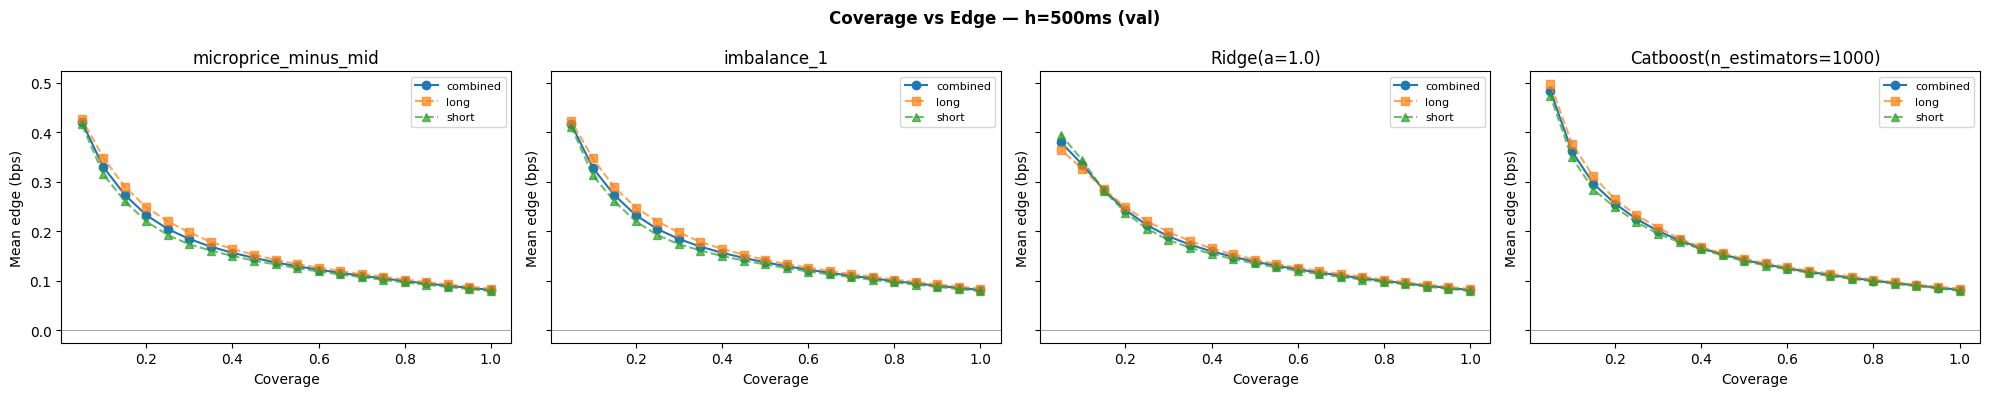

In [83]:
# Coverage vs edge plot
fig, axes = plt.subplots(1, len(scores_val), figsize=(5 * len(scores_val), 4), sharey=True)
if len(scores_val) == 1:
    axes = [axes]

for ax, (bl_name, sc) in zip(axes, scores_val.items()):
    ce = coverage_edge_sweep(sc, val_label)
    ax.plot(ce["coverage"], ce["mean_edge_bps"], "o-", label="combined")
    ax.plot(ce["coverage"], ce["long_edge_bps"], "s--", alpha=0.7, label="long")
    ax.plot(ce["coverage"], ce["short_edge_bps"], "^--", alpha=0.7, label="short")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Mean edge (bps)")
    ax.set_title(bl_name)
    ax.legend(fontsize=8)

fig.suptitle(f"Coverage vs Edge — h={horizon_ms}ms (val)", fontweight="bold")
fig.tight_layout()
plt.show()

## Validation summary

In [84]:
summary_val = eval_summary(scores_val, val_label, horizon_ms)
display(summary_val)

Summary — h=500ms


,rank_IC,top10_mean_bps,bot10_mean_bps,top5_mean_bps,bot5_mean_bps,best_edge_bps_at_5cov
baseline,,,,,,
microprice_minus_mid,0.383194,0.233586,-0.234429,0.330220,-0.327788,0.421511
imbalance_1,0.383163,0.233231,-0.234325,0.328642,-0.325026,0.416437
Ridge(a=1.0),0.381443,0.241172,-0.245829,0.329213,-0.339632,0.379922
Catboost(n_estimators=1000),0.389367,0.253202,-0.257735,0.359906,-0.364140,0.361602


## Secondary horizon check (h=1000ms)

In [93]:
ds2, meta2 = load(1000)
h2 = int(meta2["horizon_ms"])

t0_2 = ds2["timestamp"].min()
boundaries2 = [
    (t0_2, t0_2 + TRAIN_DAYS * DAY_MS, "train"),
    (t0_2 + TRAIN_DAYS * DAY_MS, t0_2 + (TRAIN_DAYS + VAL_DAYS) * DAY_MS, "val"),
    (t0_2 + (TRAIN_DAYS + VAL_DAYS) * DAY_MS, t0_2 + (TRAIN_DAYS + VAL_DAYS + TEST_DAYS) * DAY_MS, "test"),
]

parts2 = split_and_purge(ds2, h2, boundaries2)
train2, val2, test2 = parts2["train"], parts2["val"], parts2["test"]

baselines2 = [
    SingleFeatureBaseline("microprice_minus_mid"),
    SingleFeatureBaseline("imbalance_1"),
    RidgeBaseline(alpha=1.0),
    CatboostBaseline(n_estimators=1000),
]

scores_val2 = {}
for bl in baselines2:
    bl.fit(train2, train2[LABEL_COL])
    scores_val2[bl.name] = bl.predict(val2)

summary_val2 = eval_summary(scores_val2, val2[LABEL_COL].values, h2)
display(summary_val2)

  Purged 9 rows from train tail
  Purged 9 rows from val tail
train:  1,692,842 rows  [2026-03-23 20:37:35.300000+00:00 → 2026-03-25 20:37:34.300000+00:00]
  val:    851,356 rows  [2026-03-25 20:37:35.300000+00:00 → 2026-03-26 20:37:34.300000+00:00]
 test:    858,046 rows  [2026-03-26 20:37:35.300000+00:00 → 2026-03-27 20:27:39.800000+00:00]
Summary — h=1000ms


,rank_IC,top10_mean_bps,bot10_mean_bps,top5_mean_bps,bot5_mean_bps,best_edge_bps_at_5cov
baseline,,,,,,
microprice_minus_mid,0.416642,0.356640,-0.359257,0.477837,-0.476427,0.581012
imbalance_1,0.416714,0.356034,-0.360082,0.476514,-0.475361,0.577261
Ridge(a=1.0),0.413914,0.362623,-0.371119,0.468182,-0.480792,0.529264
Catboost(n_estimators=1000),0.418123,0.371346,-0.378010,0.495412,-0.502059,0.498198


## Bucket analysis comparison (primary vs secondary)

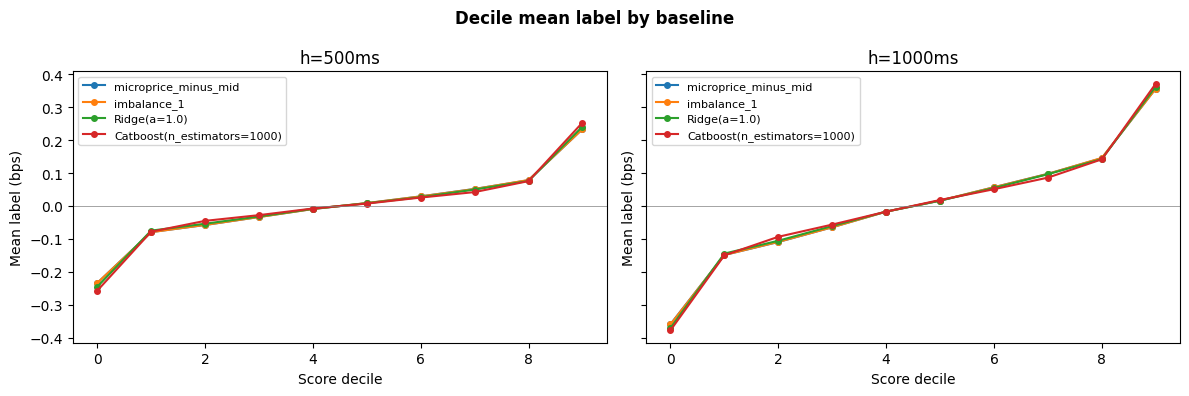

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (h_label, bl_set, vdf) in zip(axes, [
    (f"h={horizon_ms}ms", baselines, val_df),
    (f"h={h2}ms", baselines2, val2),
]):
    label_arr = vdf[LABEL_COL].values
    for bl in bl_set:
        sc = bl.predict(vdf)
        ba = bucket_analysis(sc, label_arr)
        ax.plot(ba.index, ba["mean_label_bps"], "o-", label=bl.name, markersize=4)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("Score decile")
    ax.set_ylabel("Mean label (bps)")
    ax.set_title(h_label)
    ax.legend(fontsize=8)

fig.suptitle("Decile mean label by baseline", fontweight="bold")
fig.tight_layout()
plt.show()

## Final test evaluation

Best baseline selected on val is evaluated on the held-out test day.
Baselines are fitted on train only (same models as val evaluation).

In [95]:
# Select best baseline by rank IC on val
best_bl_name = summary_val["rank_IC"].idxmax()
print(f"Best baseline on val: {best_bl_name}\n")

# Score all baselines on test for comparison, but decision was made on val
test_label = test_df[LABEL_COL].values
scores_test = {}
for bl in baselines:
    scores_test[bl.name] = bl.predict(test_df)

summary_test = eval_summary(scores_test, test_label, horizon_ms)
display(summary_test)

Best baseline on val: Catboost(n_estimators=1000)

Summary — h=500ms


,rank_IC,top10_mean_bps,bot10_mean_bps,top5_mean_bps,bot5_mean_bps,best_edge_bps_at_5cov
baseline,,,,,,
microprice_minus_mid,0.389836,0.258808,-0.267696,0.367553,-0.378824,0.490735
imbalance_1,0.389951,0.260287,-0.266254,0.370445,-0.375982,0.489496
Ridge(a=1.0),0.388680,0.272598,-0.284217,0.377845,-0.404226,0.427600
Catboost(n_estimators=1000),0.400949,0.293588,-0.305296,0.415367,-0.437009,0.561804


In [96]:
# Test: bucket analysis for best baseline
print(f"Bucket analysis on test — {best_bl_name}")
display(bucket_analysis(scores_test[best_bl_name], test_label))

Bucket analysis on test — Catboost(n_estimators=1000)


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,85809,-2.121581,-0.305296,0.016910,0.370019
1,85807,-0.685285,-0.098613,0.015710,0.138753
2,85803,-0.322433,-0.046398,0.015804,0.075533
3,85802,-0.184274,-0.026517,0.019813,0.053227
4,85814,-0.070233,-0.010107,0.025986,0.035903
5,85797,0.047949,0.006900,0.037088,0.027099
6,85804,0.154297,0.022203,0.051524,0.021782
7,85805,0.321405,0.046250,0.080392,0.017680
8,85805,0.627846,0.090347,0.144607,0.019300


In [97]:
# Test: tail stats for best baseline
print(f"Tail stats on test — {best_bl_name}")
display(tail_stats(scores_test[best_bl_name], test_label))

Tail stats on test — Catboost(n_estimators=1000)


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42903,-3.036883,-0.437009,0.477338,0.018111,0.510757
top_5%,42903,2.886486,0.415367,0.473118,0.513997,0.024497
bottom_10%,85809,-2.121581,-0.305296,0.342231,0.016910,0.370019
top_10%,85806,2.040215,0.293588,0.345627,0.379088,0.023728


In [98]:
# Test: coverage vs edge for best baseline
print(f"Coverage vs edge on test — {best_bl_name}")
ce_test = coverage_edge_sweep(scores_test[best_bl_name], test_label)
display(ce_test)

Coverage vs edge on test — Catboost(n_estimators=1000)


,threshold,coverage,n_trades,mean_edge,mean_edge_bps,long_n,long_edge_bps,short_n,short_edge_bps
0,0.000002,0.999997,858048,0.657670,0.094639,420126,0.093819,437922,0.095425
1,0.026093,0.949999,815148,0.691320,0.099481,402196,0.098039,412952,0.100886
2,0.050145,0.899999,772245,0.727125,0.104634,383043,0.102589,389202,0.106646
3,0.076754,0.849998,729342,0.765211,0.110114,361248,0.108033,368094,0.112157
4,0.107421,0.799999,686440,0.807040,0.116133,338527,0.114394,347913,0.117826
5,0.142425,0.750000,643538,0.853503,0.122820,315129,0.121651,328409,0.123941
6,0.182213,0.699999,600635,0.903877,0.130068,292793,0.129291,307842,0.130807
7,0.223723,0.650000,557733,0.958630,0.137947,270916,0.137764,286817,0.138120
8,0.269532,0.599993,514825,1.020802,0.146894,249373,0.147106,265452,0.146694
9,0.313644,0.550000,471928,1.090497,0.156923,227960,0.157432,243968,0.156448


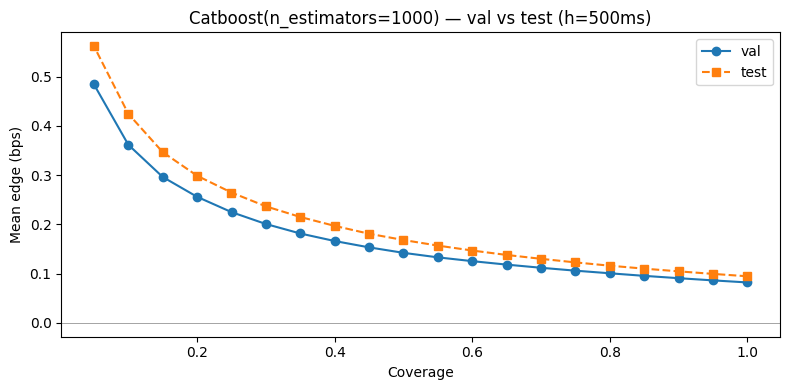

In [99]:
# Test vs Val comparison plot for best baseline
fig, ax = plt.subplots(figsize=(8, 4))

ce_val = coverage_edge_sweep(scores_val[best_bl_name], val_label)
ax.plot(ce_val["coverage"], ce_val["mean_edge_bps"], "o-", label="val")
ax.plot(ce_test["coverage"], ce_test["mean_edge_bps"], "s--", label="test")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Coverage")
ax.set_ylabel("Mean edge (bps)")
ax.set_title(f"{best_bl_name} — val vs test (h={horizon_ms}ms)")
ax.legend()
fig.tight_layout()
plt.show()

## Research verdict

Interpretation guidelines for the auto-generated verdict below:
- **Ranking signal**: Spearman IC > 0.05 with stable decile monotonicity
- **Tail concentration**: top5 - bottom5 spread > 0.1 bps
- **Abstain zone**: edge at 30-60% coverage meaningfully exceeds full-coverage edge
- **Test confirmation**: test metrics within reasonable range of val (no overfitting)

In [100]:
print("=" * 60)
print("RESEARCH VERDICT")
print("=" * 60)

best_bl = summary_val["rank_IC"].idxmax()
best_ic_val = summary_val.loc[best_bl, "rank_IC"]
best_ic_test = summary_test.loc[best_bl, "rank_IC"]
print(f"\nBest baseline: {best_bl}")
print(f"  val  rank IC = {best_ic_val:.4f}")
print(f"  test rank IC = {best_ic_test:.4f}")

# Ranking signal
has_ranking = best_ic_val > 0.05 and best_ic_test > 0.05
print(f"\nIs ranking signal present: {'YES' if has_ranking else 'NO'}")

# Tail concentration
top5_val = summary_val.loc[best_bl, "top5_mean_bps"]
bot5_val = summary_val.loc[best_bl, "bot5_mean_bps"]
top5_test = summary_test.loc[best_bl, "top5_mean_bps"]
bot5_test = summary_test.loc[best_bl, "bot5_mean_bps"]
spread_val = top5_val - bot5_val
spread_test = top5_test - bot5_test
tail_concentrated = spread_val > 0.1 and spread_test > 0.1
print(f"Does edge concentrate in tails: {'YES' if tail_concentrated else 'NO'}")
print(f"  val  top5/bot5 spread = {spread_val:.4f} bps")
print(f"  test top5/bot5 spread = {spread_test:.4f} bps")

# Abstain zone
ce_val_best = coverage_edge_sweep(scores_val[best_bl], val_label)
ce_full = ce_val_best[ce_val_best["coverage"] > 0.95]
ce_half = ce_val_best[(ce_val_best["coverage"] >= 0.3) & (ce_val_best["coverage"] <= 0.6)]
full_edge = ce_full["mean_edge_bps"].mean() if len(ce_full) > 0 else 0
half_edge = ce_half["mean_edge_bps"].mean() if len(ce_half) > 0 else 0
abstain_useful = half_edge > full_edge * 1.5 if full_edge != 0 else half_edge > 0
print(f"Is abstain zone useful: {'YES' if abstain_useful else 'NO'}")
print(f"  full coverage edge = {full_edge:.4f} bps, mid coverage edge = {half_edge:.4f} bps")

# Horizon
ic_h1000 = summary_val2["rank_IC"].max()
print(f"\nPrimary horizon confirmed (h=500): {'YES' if best_ic_val >= ic_h1000 * 0.8 else 'NO'}")
print(f"  h500 val IC = {best_ic_val:.4f}, h1000 val IC = {ic_h1000:.4f}")

# Test stability
ic_ratio = best_ic_test / best_ic_val if best_ic_val != 0 else 0
test_stable = 0.7 < ic_ratio < 1.3
print(f"\nTest confirms val: {'YES' if test_stable else 'NO'} (test/val IC ratio = {ic_ratio:.3f})")

print(f"\nRecommended next step: ", end="")
if has_ranking and tail_concentrated and test_stable:
    print("Proceed to nonlinear model (LightGBM) to improve tail concentration.")
elif has_ranking:
    print("Signal present but tails weak or unstable. Try feature engineering or longer horizon.")
else:
    print("No ranking signal. Revisit features or data quality.")

RESEARCH VERDICT

Best baseline: Catboost(n_estimators=1000)
  val  rank IC = 0.3894
  test rank IC = 0.4009

Is ranking signal present: YES
Does edge concentrate in tails: YES
  val  top5/bot5 spread = 0.7240 bps
  test top5/bot5 spread = 0.8524 bps
Is abstain zone useful: YES
  full coverage edge = 0.0821 bps, mid coverage edge = 0.1503 bps

Primary horizon confirmed (h=500): YES
  h500 val IC = 0.3894, h1000 val IC = 0.4181

Test confirms val: YES (test/val IC ratio = 1.030)

Recommended next step: Proceed to nonlinear model (LightGBM) to improve tail concentration.
